In [30]:
import logging
import os

from openretina.utils.transformer_utils import extract_attention_maps,  extract_temporal_attention_maps
from openretina.data_io.hoefling_2024.stimuli import movies_from_pickle

from openretina.utils.misc import CustomPrettyPrinter
from openretina.utils.plotting import (
    numpy_to_mp4_video,
)
from openretina.models.core_readout import UnifiedCoreReadout
from openretina.utils.h5_handling import load_h5_into_dict
from openretina.data_io.hoefling_2024.responses import filter_responses, make_final_responses

from openretina.data_io.cyclers import LongCycler, ShortCycler
from openretina.data_io.hoefling_2024.dataloaders import natmov_dataloaders_v2
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)  # to display logs in jupyter notebooks
import os
from openretina.data_io.base import compute_data_info
import hydra
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pp = CustomPrettyPrinter(indent=4, max_lines=40)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
movie_stimulus_path = '/home/bethge/bkr618/openretina_cache/euler_lab/hoefling_2024/stimuli/rgc_natstim_72x64_joint_normalized_2024-10-11.pkl'

movie_stimuli = movies_from_pickle(movie_stimulus_path)

In [3]:
with hydra.initialize(config_path=os.path.join("..", "configs"), version_base="1.3"):
    cfg = hydra.compose(config_name="hoefling_2024_core_readout_low_res.yaml")

In [4]:
responses_path = "/home/bethge/bkr618/openretina_cache/data/euler_lab/hoefling_2024/responses/rgc_natstim_2024-08-14.h5"

responses_dict = load_h5_into_dict(file_path=responses_path)

filtered_responses_dict = filter_responses(responses_dict, **cfg.quality_checks)

final_responses = make_final_responses(filtered_responses_dict, response_type="natural")

Loading HDF5 file contents:   0%|          | 0/2077 [00:00<?, ?item/s]

Original dataset contains 7863 neurons over 67 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (67 remaining)
Overall, dropped 3034 neurons of non-target cell types (-38.59%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (67 remaining)
Overall, dropped 980 neurons over quality checks (-20.29%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 705 neurons with classifier confidences below 0.25 (-18.32%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 3144 neurons over 67 fields
Total number of cells dropped: 4719 (-60.02%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/67 [00:00<?, ?it/s]

In [5]:
data_info = compute_data_info(neuron_data_dictionary=final_responses, movies_dictionary=movie_stimuli)
n_neurons_dict = data_info["n_neurons_dict"]

In [ ]:
file_path = "/mnt/lustre/work/bethge/bkr618/hyperparams_search/openretina_assets/runs/high_reg/2025-12-08_10-28-36/checkpoints/epoch=24_val_correlation=0.209.ckpt"
model = UnifiedCoreReadout.load_from_checkpoint(file_path, map_location="cuda", n_neurons_dict = n_neurons_dict)

In [7]:
dataloaders = natmov_dataloaders_v2(
    neuron_data_dictionary=final_responses,
    movies_dictionary=movie_stimuli,
    allow_over_boundaries=True,
    batch_size=64,
    train_chunk_size=50,
    validation_clip_indices=cfg.dataloader.validation_clip_indices,
)

Creating movie dataloaders:   0%|          | 0/67 [00:00<?, ?it/s]

In [8]:

train_loader = LongCycler(dataloaders["train"])
val_loader = ShortCycler(dataloaders["validation"])

In [9]:
test_loader = ShortCycler(dataloaders["test"])

In [10]:
import lightning
trainer =  lightning.Trainer(max_epochs=100, precision = '16-mixed') #add precision

trainer.test(model, dataloaders=[train_loader, val_loader, test_loader])

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_correlation      │    0.1777712106704712     │    0.20949095487594604    │    0.40702736377716064    │
│         test_loss         │     270.7438049316406     │     356.5923156738281     │    36.216583251953125     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

[{'test_loss/dataloader_idx_0': 270.7438049316406,
  'test_correlation/dataloader_idx_0': 0.1777712106704712},
 {'test_loss/dataloader_idx_1': 356.5923156738281,
  'test_correlation/dataloader_idx_1': 0.20949095487594604},
 {'test_loss/dataloader_idx_2': 36.216583251953125,
  'test_correlation/dataloader_idx_2': 0.40702736377716064}]

In [26]:
results = extract_attention_maps(
    pl_module=model,
    val_dataloader=test_loader,
    target_session="session_3_ventral2_20201022",
    outdir="/home/bethge/bkr618/openretina_cache/attn_sparse",
    device='cuda',
    neuron_idx=11,  # Which neuron to visualize
    head_idx=2,     # Which attention head
    batch_idx=0      # Which batch from the dataloader
)


Video shape: torch.Size([1, 2, 750, 72, 64])
Temporal params: kernel=35, stride=1
Number of patches: 716, centers at: [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209,

In [21]:
A = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_3_ventral2_20201022_b0_neuron11_head3_overlaid.npy") #11,0,10,20
#A = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_2_ventral1_20210929_b0_neuron30_head1_overlaid.npy")
A = A.transpose(3,0,1,2)
numpy_to_mp4_video(A, save_path = "/home/bethge/bkr618/openretina_cache/attn_sparse/high_quality.mp4",fps=30)

In [27]:
A = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_3_ventral2_20201022_b0_neuron11_head3_overlaid.npy")
B = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_3_ventral2_20201022_b0_neuron11_head2_overlaid.npy")
C = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_3_ventral2_20201022_b0_neuron11_head1_overlaid.npy")
D = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_3_ventral2_20201022_b0_neuron11_head0_overlaid.npy")

A = A.transpose(3,0,1,2)
B = B.transpose(3,0,1,2)
C = C.transpose(3,0,1,2)
D = D.transpose(3,0,1,2)
vids = np.concat([A,B,C, D], axis=3)  # shape: (T, C, H, W1 + W2)

numpy_to_mp4_video(vids,save_path="/home/bethge/bkr618/openretina_cache/attn_sparse/4_heads.mp4", fps=30)

In [19]:
A = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron0_head0_overlaid.npy")
B = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron1_head0_overlaid.npy")
C = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron2_head0_overlaid.npy")
D = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron3_head0_overlaid.npy")

A = A.transpose(3,0,1,2)
B = B.transpose(3,0,1,2)
C = C.transpose(3,0,1,2)
D = D.transpose(3,0,1,2)
vids = np.concat([A,B,C, D], axis=3)  # shape: (T, C, H, W1 + W2)

numpy_to_mp4_video(vids, fps=30)

In [26]:
A = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron12_head1_spatial_overlaid.npy")
B = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron13_head1_spatial_overlaid.npy")
C = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron5_head1_spatial_overlaid.npy")
D = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron10_head1_spatial_overlaid.npy")

A = A.transpose(3,0,1,2)
B = B.transpose(3,0,1,2)
C = C.transpose(3,0,1,2)
D = D.transpose(3,0,1,2)
vids = np.concat([A,B,C, D], axis=3)  # shape: (T, C, H, W1 + W2)

numpy_to_mp4_video(vids, fps=30)

In [31]:
A = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron12_head2_spatial_overlaid.npy")
B = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron13_head2_spatial_overlaid.npy")
C = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron5_head2_spatial_overlaid.npy")
D = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron10_head2_spatial_overlaid.npy")

A = A.transpose(3,0,1,2)
B = B.transpose(3,0,1,2)
C = C.transpose(3,0,1,2)
D = D.transpose(3,0,1,2)
vids = np.concat([A,B,C, D], axis=3)  # shape: (T, C, H, W1 + W2)

numpy_to_mp4_video(vids, fps=30)

In [36]:
A = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron12_head3_spatial_overlaid.npy")
B = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron13_head3_spatial_overlaid.npy")
C = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron5_head3_spatial_overlaid.npy")
D = np.load("/home/bethge/bkr618/openretina_cache/attn_sparse/session_1_ventral2_20210921_b0_neuron10_head3_spatial_overlaid.npy")

A = A.transpose(3,0,1,2)
B = B.transpose(3,0,1,2)
C = C.transpose(3,0,1,2)
D = D.transpose(3,0,1,2)
vids = np.concat([A,B,C, D], axis=3)  # shape: (T, C, H, W1 + W2)

numpy_to_mp4_video(vids, fps=30)

In [39]:
attention = extract_temporal_attention_maps(
    pl_module=model,
    val_dataloader=test_loader,
    target_session="session_3_ventral2_20201022",
    outdir="/home/bethge/bkr618/openretina_cache/attn_sparse",
    device='cuda',
    neuron_idx=15,  # Which neuron to visualize
    head_idx=2,     # Which attention head
    batch_idx=0      # Which batch from the dataloader
)

Video shape: torch.Size([1, 2, 750, 72, 64])
Temporal params: kernel=35, stride=1
Number of patches: 716, centers at: [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209,

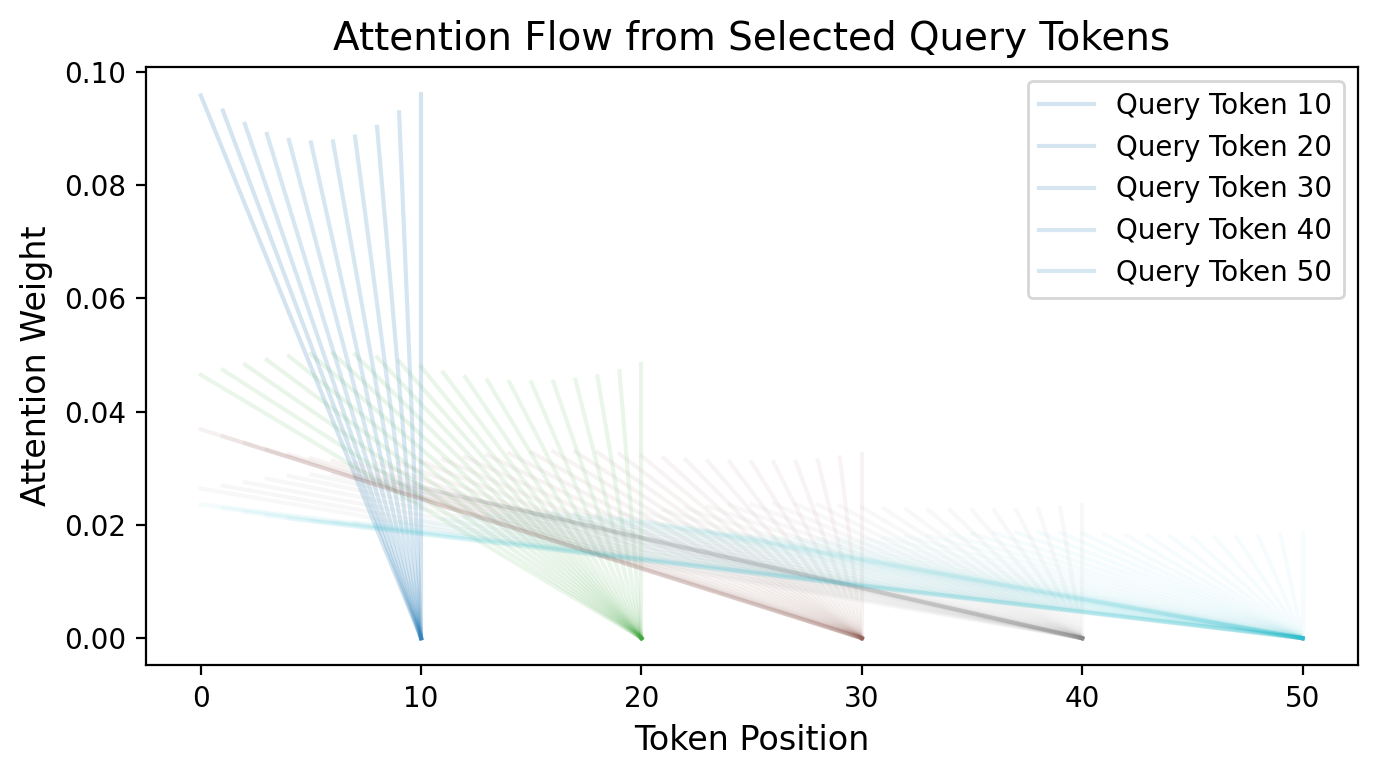

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

attention_map = attention.mean(axis = 0)  
attention_np = attention_map  

# METHOD 1: Attention Flow Curves (inspired by attention head visualizations)
# Shows how specific tokens attend to others as flowing curves
def plot_attention_curves(attention_np, query_indices=[10,20,30,40,50]):
    """Visualize attention as curves from query tokens to key tokens"""
    fig, ax = plt.subplots(figsize=(7, 4))
    
    n_tokens = attention_np.shape[0]
    token_positions = np.arange(n_tokens)
    
    # Create gradient of colors for different query tokens
    colors = plt.cm.tab10(np.linspace(0, 1, len(query_indices)))
    
    for idx, query_idx in enumerate(query_indices):
        attention_weights = attention_np[query_idx, :]
        
        # Only plot attention above threshold for clarity
        threshold = np.percentile(attention_weights, 90)
        significant_tokens = attention_weights > threshold
        
        # Plot as line with varying alpha based on attention strength
        for key_idx in np.where(significant_tokens)[0]:
            weight = float(attention_weights[key_idx])  # Convert to Python float
            alpha = min(weight * 2, 1.0)  # Scale alpha
            
            # Draw curve from query to key position
            x = [query_idx, key_idx]
            y = [0, weight]
            ax.plot(x, y, color=colors[idx], alpha=alpha, linewidth=1.5)
    
    ax.set_xlabel('Token Position', fontsize=12)
    ax.set_ylabel('Attention Weight', fontsize=12)
    ax.set_title('Attention Flow from Selected Query Tokens', fontsize=14)
    ax.legend([f'Query Token {i}' for i in query_indices], loc='upper right')
    plt.tight_layout()

    plt.show()


plot_attention_curves(attention_np)


Generating normalized attention visualizations...


/tmp/ipykernel_3529497/1717212391.py:66: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  normalized = attention_map / visibility[np.newaxis, :]


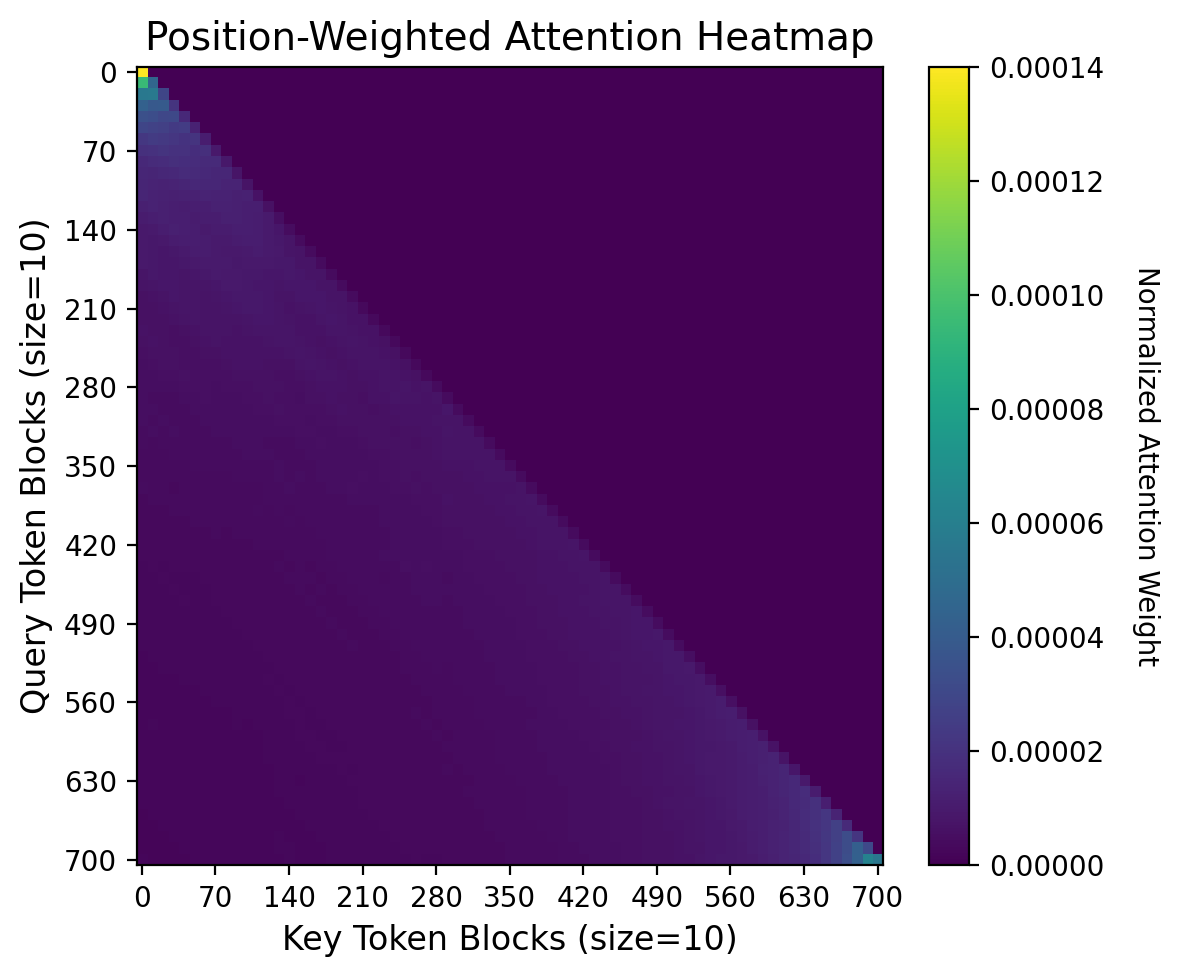

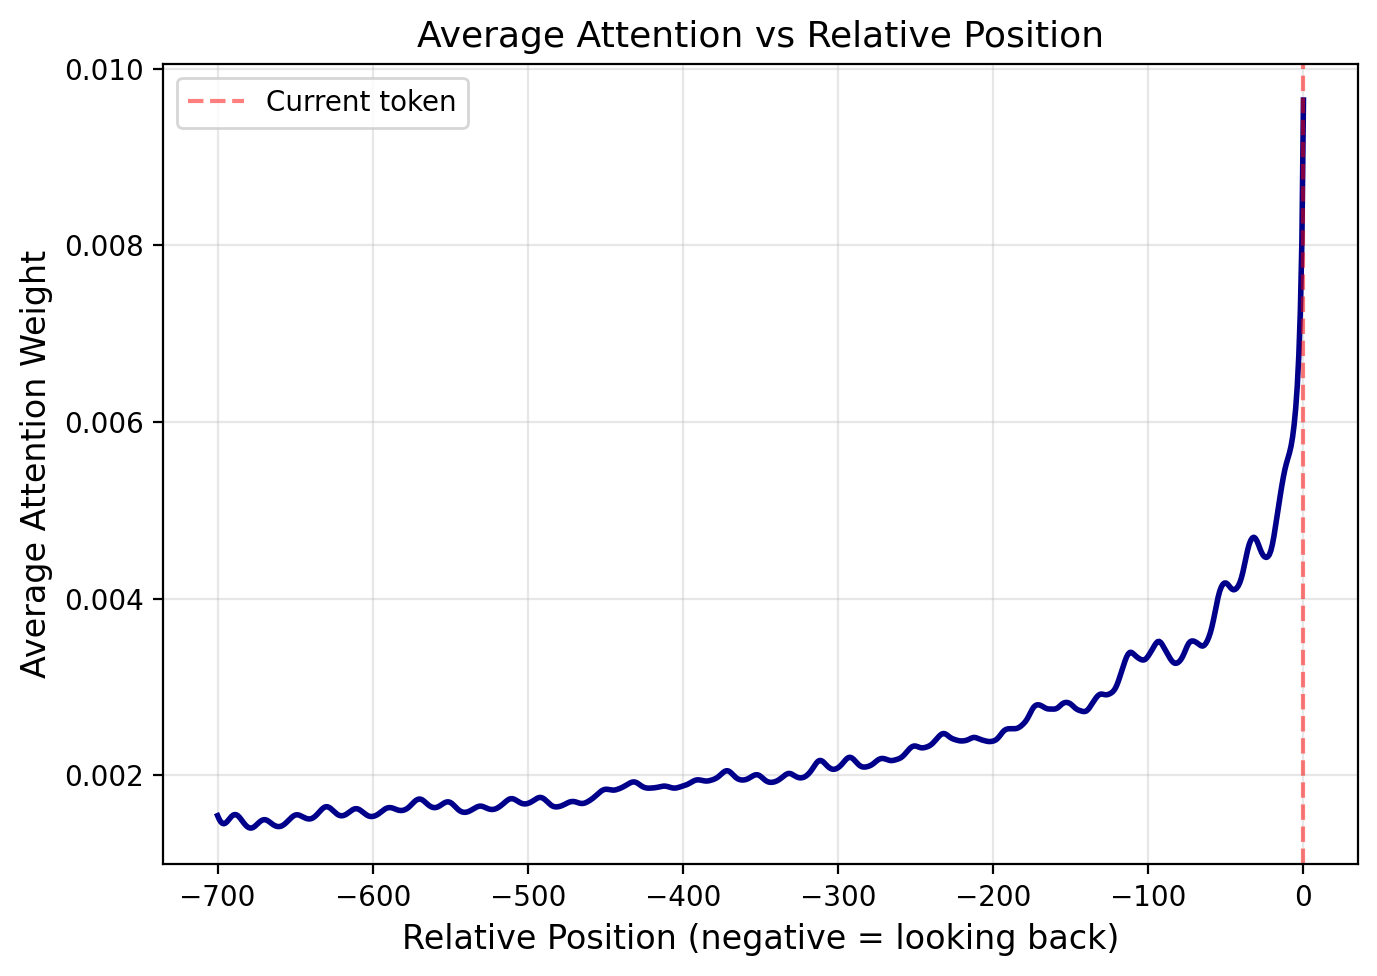

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have your attention map as a numpy array
n_tokens = attention_map.shape[0]

# Apply causal mask for demonstration (remove if your data already has it)
causal_mask = np.tril(np.ones((n_tokens, n_tokens)))
attention_map = attention_map #* causal_mask

# NORMALIZATION METHODS FOR FAIRER COMPARISON

def get_position_weighted_attention(attention_map):
    """
    Method 1: Normalize by position visibility
    Token at position i can only be seen by tokens i, i+1, ..., n-1
    So token 0 is seen by all n tokens, token n-1 only by itself
    """
    n_tokens = attention_map.shape[0]
    
    # Count how many tokens can see each position
    visibility_count = np.arange(n_tokens, 0, -1)  # [n, n-1, n-2, ..., 1]
    
    # Sum attention received by each token
    attention_received = attention_map.sum(axis=0)  # Shape: (n_tokens,)
    
    # Normalize by visibility: divide by number of tokens that can see it
    normalized_attention = attention_received / visibility_count
    
    return normalized_attention, visibility_count

def get_normalized_attention_map(attention_map):
    """
    Normalize attention map so that each value is between 0 and 1.
    """
    n_tokens = attention_map.shape[0]
    normalized_map = np.zeros_like(attention_map, dtype=float)
    
    for i in range(n_tokens):
        # Token i can attend to tokens 0 to i (inclusive)
        num_visible = i + 1
        row = attention_map[i, :] / num_visible
        
        # Normalize row to [0,1]
        max_val = row.max()
        if max_val > 0:
            row = row / max_val
        
        normalized_map[i, :] = row
    
    return normalized_map




def plot_normalized_heatmap(attention_map, method='position_weighted'):
    """
    Plot heatmap with normalization applied
    method: 'position_weighted' or 'per_query'
    """
    n_tokens = attention_map.shape[0]
    
    if method == 'position_weighted':
        # Normalize each column by its visibility count
        visibility = np.arange(n_tokens, 0, -1)
        normalized = attention_map / visibility[np.newaxis, :]
        title = 'Position-Weighted Attention Heatmap'
        
    elif method == 'per_query':
        # Normalize each row by number of visible tokens
        normalized = np.zeros_like(attention_map)
        for i in range(n_tokens):
            num_visible = i + 1
            normalized[i, :i+1] = attention_map[i, :i+1] / num_visible
        title = 'Per-Query Normalized Attention Heatmap'
    
    # Downsample for visibility
    block_size = 10
    n_blocks = n_tokens // block_size
    block_attention = np.zeros((n_blocks, n_blocks))
    
    for i in range(n_blocks):
        for j in range(n_blocks):
            block_attention[i, j] = normalized[
                i*block_size:(i+1)*block_size,
                j*block_size:(j+1)*block_size
            ].mean()
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(block_attention, cmap='viridis', aspect='auto')
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Normalized Attention Weight', rotation=270, labelpad=20)
    
    tick_positions = np.arange(0, n_blocks, max(1, n_blocks // 10))
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels([f'{i*block_size}' for i in tick_positions])
    ax.set_yticklabels([f'{i*block_size}' for i in tick_positions])
    
    ax.set_xlabel(f'Key Token Blocks (size={block_size})', fontsize=12)
    ax.set_ylabel(f'Query Token Blocks (size={block_size})', fontsize=12)
    ax.set_title(title, fontsize=14)
    
    plt.tight_layout()

    plt.show()

def plot_attention_per_query_position(attention_map):
    """
    Show how attention is distributed from each query position
    This naturally accounts for causal masking
    """
    fig, ax2= plt.subplots(1, 1, figsize=(7, 5))
    
 
    # Average attention to relative positions
    relative_attention = []
    counts = []
    
    max_lookback = 700  # Look at relative positions -100 to 0
    for rel_pos in range(-max_lookback, 1):
        weights = []
        for q_pos in range(abs(rel_pos), n_tokens):
            k_pos = q_pos + rel_pos
            if k_pos >= 0:
                weights.append(attention_map[q_pos, k_pos])
        if weights:
            relative_attention.append(np.mean(weights))
            counts.append(len(weights))
    
    ax2.plot(range(-max_lookback, 1), relative_attention, linewidth=2, color='darkblue')
    ax2.set_xlabel('Relative Position (negative = looking back)', fontsize=12)
    ax2.set_ylabel('Average Attention Weight', fontsize=12)
    ax2.set_title('Average Attention vs Relative Position', fontsize=13)
    ax2.grid(alpha=0.3)
    ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Current token')
    ax2.legend()
    
    plt.tight_layout()

    plt.show()

# Run all visualizations
print("Generating normalized attention visualizations...")

plot_normalized_heatmap(attention_map, method='position_weighted')

plot_attention_per_query_position(attention_map)